In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## Time Series Analyses of NDVI, ET, Albedo, and LST in the Forest Area of Bavaria

In [4]:
import ee
import datetime  
import matplotlib.pyplot as plt
import geemap
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from scipy.stats import linregress
from scipy.stats import stats
import pandas as pd

PROJECT_NAME='xxx'
ee.Initialize(project=PROJECT_NAME)


ASSET="xxx" # insert path
bayern = ee.FeatureCollection(ASSET)


In [5]:
# Stable forest area -> forest loss or afforestation excluded

lc00 = ee.Image("COPERNICUS/CORINE/V20/100m/2000").select("landcover")
lc18 = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

forest = lc00.eq(311).Or(lc00.eq(312)).Or(lc00.eq(313)).And(lc18.eq(311).Or(lc18.eq(312)).Or(lc18.eq(313))).selfMask().clip(bayern)

Forest conversion area (2001 to 2024): 2602.42 km²


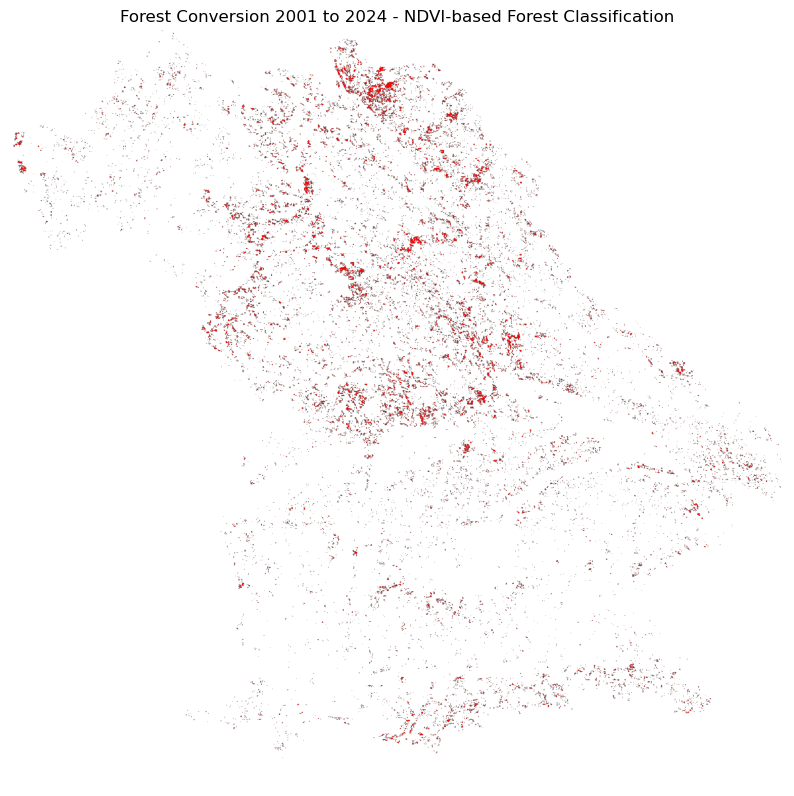

In [3]:
### Forest Conversion 2001 - 2024


def get_ndvi(img):
    return img.select("NDVI").multiply(0.0001).copyProperties(img, ["system:time_start"])

def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)
NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).map(get_ndvi)


modis_proj = NDVI.first().projection()


def season_mean(year, months):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    winter = season_mean(year, [1,2,3])
    summer = season_mean(year, [5,6,7])

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .updateMask(forest) # stable forest area
        .clip(bayern)
        .reproject(modis_proj)  

    )

    return class_img


class_2001 = classify_forest(2001)
class_2024 = classify_forest(2024)


# Needleleaf 2001 → Broadleaf/mixed 2024
conversion = (
    class_2001.eq(1)
    .And(class_2024.eq(2))
).selfMask().rename("conversion")


# Area
conversion_km2 = (
    conversion
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=bayern,
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("conversion")
    .getInfo()
) / 1e6
print(f"Forest conversion area (2001 to 2024): {conversion_km2:.2f} km²")


thumb_url = conversion.visualize(
    palette=["red"],
    min=0,
    max=1
).getThumbURL({
    "region": bayern.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Forest Conversion 2001 to 2024 - NDVI-based Forest Classification")
plt.axis("off")
plt.show()



Stable Needleleaf Area (2001 to 2024): 8794.97 km²


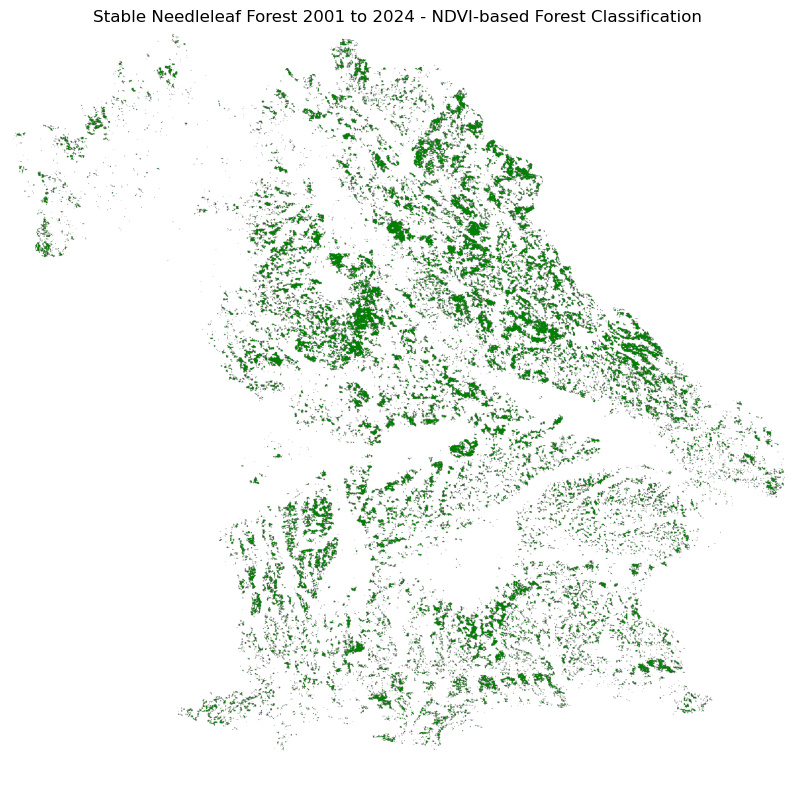

In [4]:
### Needleleaf stable 2001 - 2024



def get_ndvi(img):
    return img.select("NDVI").multiply(0.0001).copyProperties(img, ["system:time_start"])

def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)
NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).map(get_ndvi)



modis_proj = NDVI.first().projection()


def season_mean(year, months):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    winter = season_mean(year, [1,2,3])
    summer = season_mean(year, [5,6,7])

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .updateMask(forest) # stable forest area
        .clip(bayern)
        .reproject(modis_proj)
    )

    return class_img


class_2001 = classify_forest(2001)
class_2024 = classify_forest(2024)


# Needleleaf 2001 → Needleleaf 2024
needle_stable = (
    class_2001.eq(1)
    .And(class_2024.eq(1))
).selfMask().rename("needle")


# Area
needle_km2 = (
    needle_stable
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=bayern,
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("needle")
    .getInfo()
) / 1e6
print(f"Stable Needleleaf Area (2001 to 2024): {needle_km2:.2f} km²")


thumb_url = needle_stable.visualize(
    palette=["green"],
    min=0,
    max=1
).getThumbURL({
    "region": bayern.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Stable Needleleaf Forest 2001 to 2024 - NDVI-based Forest Classification")
plt.axis("off")
plt.show()





Stable Broadleaf/Mixed Area (2001 to 2024): 6996.78 km²


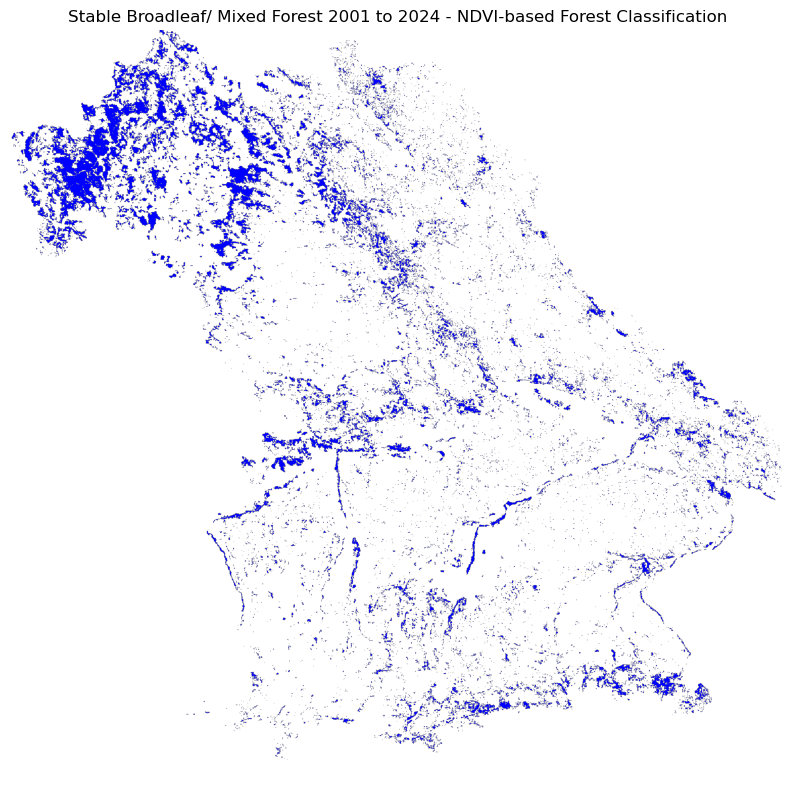

In [5]:
### Broadleaf stable 2001 - 2024


def get_ndvi(img):
    return img.select("NDVI").multiply(0.0001).copyProperties(img, ["system:time_start"])

def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)
NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).map(get_ndvi)



modis_proj = NDVI.first().projection()


def season_mean(year, months):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    winter = season_mean(year, [1,2,3])
    summer = season_mean(year, [5,6,7])

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .updateMask(forest) # stable forest area
        .clip(bayern)
        .reproject(modis_proj)
    )

    return class_img


class_2001 = classify_forest(2001)
class_2024 = classify_forest(2024)


# Broadleaf/mixed 2001 → Broadleaf/mixed 2024
broadleaf_stable = (
    class_2001.eq(2)
    .And(class_2024.eq(2))
).selfMask().rename("broadl")


# Area
broadl_km2 = (
    broadleaf_stable
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=bayern,
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("broadl")
    .getInfo()
) / 1e6
print(f"Stable Broadleaf/Mixed Area (2001 to 2024): {broadl_km2:.2f} km²")


thumb_url = broadleaf_stable.visualize(
    palette=["blue"],
    min=0,
    max=1
).getThumbURL({
    "region": bayern.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Stable Broadleaf/ Mixed Forest 2001 to 2024 - NDVI-based Forest Classification")
plt.axis("off")
plt.show()



In [2]:
# Stabiler wald -> kein Verlust und keine Aufforstung

lc00 = ee.Image("COPERNICUS/CORINE/V20/100m/2000").select("landcover")
lc18 = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

forest = lc00.eq(311).Or(lc00.eq(312)).Or(lc00.eq(313)).And(lc18.eq(311).Or(lc18.eq(312)).Or(lc18.eq(313))).selfMask().clip(bayern)

In [6]:
bayern = ee.FeatureCollection(ASSET)


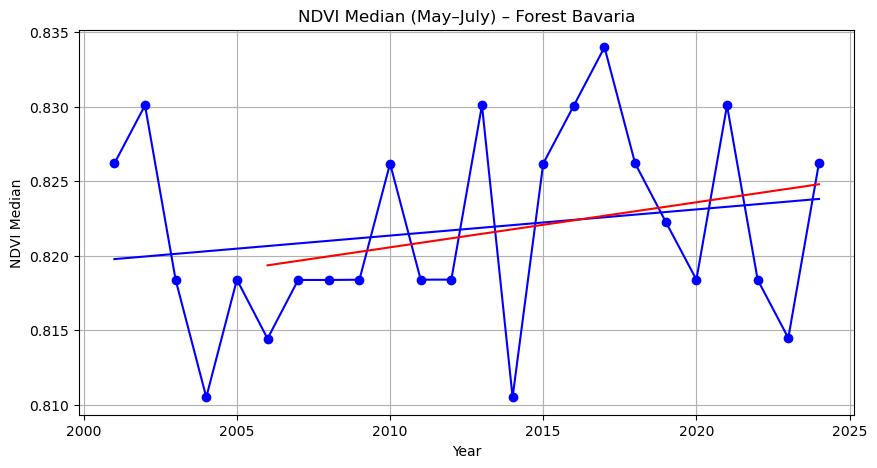

In [9]:
### NDVI growing season median of total forests with additional trendline from 2006 onwards



def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select('NDVI')

NDVI = (ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterBounds(bayern)
        .map(maskNDVI)   
 )

modis_proj = NDVI.first().projection()
NDVI_forest = NDVI.map(lambda img: img.updateMask(forest))

years = list(range(2001, 2025))
ndvi_values = []

for year in years:
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    ndvi_year = (
        NDVI_forest
        .filterDate(start, end)
        .median()
        .multiply(0.0001)
    )

    value = ndvi_year.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale = modis_proj.nominalScale(),
        maxPixels=1e13
    ).get('NDVI').getInfo()

    ndvi_values.append(value)



# Linear regression trend lines
reg_years = np.array(years)
reg_val = np.array(ndvi_values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept

years_2006 = np.array([y for y in years if y >= 2006])
values_2006 = np.array([
    v for y, v in zip(years, ndvi_values) if y >= 2006
], dtype=float)

slope_2006, intercept_2006 = np.polyfit(years_2006, values_2006,1)
trend_2006 = slope_2006 * years_2006 + intercept_2006

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, ndvi_values, marker='o', color='blue')
plt.plot(reg_years, trend, '-', color='blue')
plt.plot(years_2006, trend_2006, '-', color='red')

plt.xlabel("Year")
plt.ylabel("NDVI Median")
plt.title("NDVI Median (May–July) – Forest Bavaria")
plt.grid(True)
plt.show()


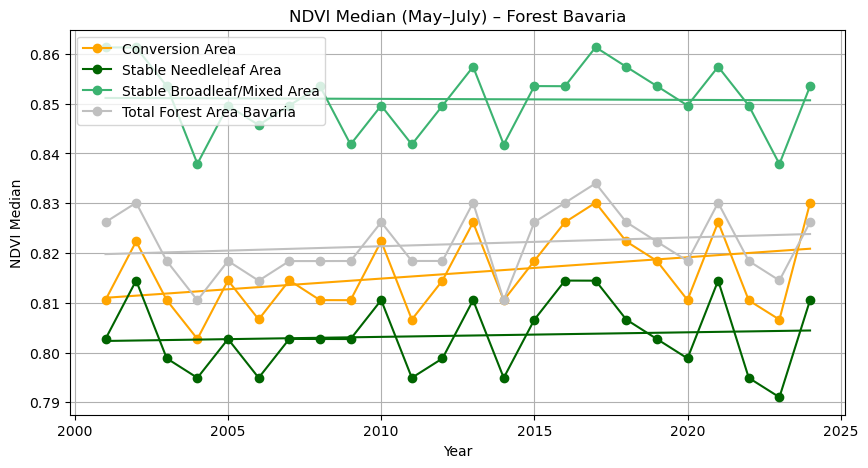


Regression for: Conversion
Slope: 0.000429
Intercept: -0.047213
R²: 0.1413
p-value: 0.070247
Standard Error: 0.000225

Regression for: Needleleaf Stable
Slope: 0.000092
Intercept: 0.619224
R²: 0.0078
p-value: 0.682408
Standard Error: 0.000221

Regression for: Broadleaf/Mixed Stable
Slope: -0.000020
Intercept: 0.892019
R²: 0.0004
p-value: 0.923457
Standard Error: 0.000210

Regression for: Total Forest Bavaria
Slope: 0.000176
Intercept: 0.468373
R²: 0.0359
p-value: 0.375352
Standard Error: 0.000194


In [8]:
### NDVI growing season medians of different forest structural classes



def maskNDVI(image):
    qc = image.select("DetailedQA")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("NDVI")


NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").filterBounds(bayern).map(maskNDVI)

modis_proj = NDVI.first().projection()
NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadl = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_forest = NDVI.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values=values(NDVI_broadl)
bayern_values=values(NDVI_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label="Total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("NDVI Median")
plt.title("NDVI Median (May–July) – Forest Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")




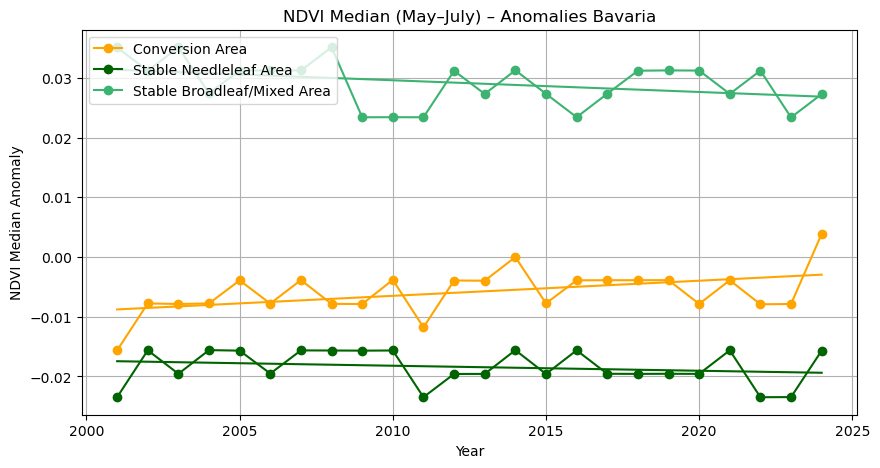


Regression for: Conversion
Slope: 0.000253
Intercept: -0.515585
R²: 0.2188
p-value: 0.021183
Standard Error: 0.000102

Regression for: Needleleaf Stable
Slope: -0.000084
Intercept: 0.150851
R²: 0.0409
p-value: 0.343311
Standard Error: 0.000087

Regression for: Broadleaf/Mixed Stable
Slope: -0.000196
Intercept: 0.423646
R²: 0.1319
p-value: 0.081046
Standard Error: 0.000107


In [10]:
### NDVI growing season anomalies of different forest structural classes


def maskNDVI(image):
    qc = image.select("DetailedQA")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("NDVI")


NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").filterBounds(bayern).map(maskNDVI)
modis_proj = NDVI.first().projection()

NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadl = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_forest = NDVI.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values=values(NDVI_broadl)
bayern_values=values(NDVI_forest)

# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("NDVI Median Anomaly")
plt.title("NDVI Median (May–July) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

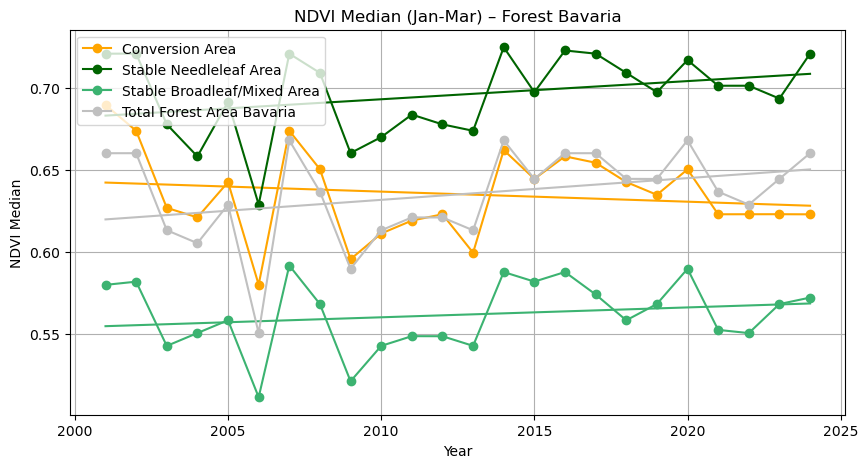


Regression for: Conversion
Slope: -0.000612
Intercept: 1.867716
R²: 0.0271
p-value: 0.441796
Standard Error: 0.000782

Regression for: Needleleaf Stable
Slope: 0.001105
Intercept: -1.528482
R²: 0.0960
p-value: 0.140721
Standard Error: 0.000723

Regression for: Broadleaf/Mixed Stable
Slope: 0.000600
Intercept: -0.646616
R²: 0.0396
p-value: 0.351532
Standard Error: 0.000631

Regression for: Total Forest Bavaria
Slope: 0.001322
Intercept: -2.026124
R²: 0.1076
p-value: 0.117690
Standard Error: 0.000812


In [11]:
### NDVI winter season medians of different forest structural classes



def maskNDVI(image):
    qc = image.select("DetailedQA")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("NDVI")


NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").filterBounds(bayern).map(maskNDVI)
modis_proj = NDVI.first().projection()

NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadl = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_forest = NDVI.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values=values(NDVI_broadl)
bayern_values=values(NDVI_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label="Total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("NDVI Median")
plt.title("NDVI Median (Jan-Mar) – Forest Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

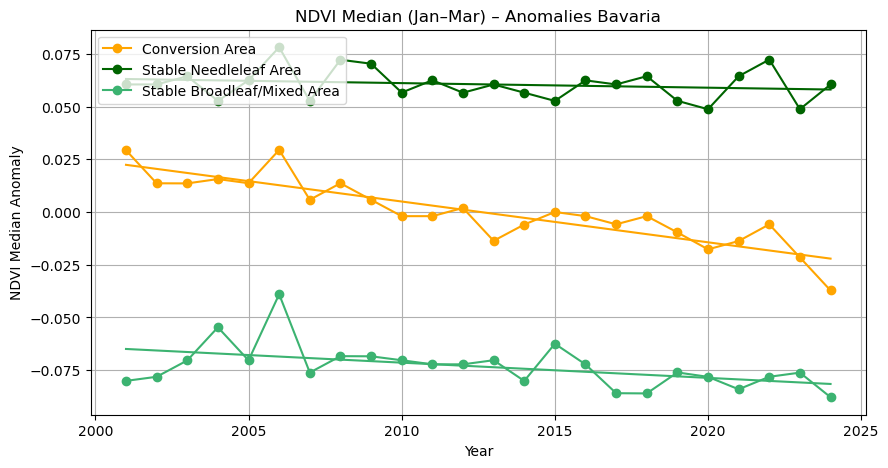


Regression for: Conversion
Slope: -0.001935
Intercept: 3.893839
R²: 0.7775
p-value: 0.000000
Standard Error: 0.000221

Regression for: Needleleaf Stable
Slope: -0.000217
Intercept: 0.497641
R²: 0.0415
p-value: 0.339673
Standard Error: 0.000222

Regression for: Broadleaf/Mixed Stable
Slope: -0.000722
Intercept: 1.379507
R²: 0.2337
p-value: 0.016715
Standard Error: 0.000279


In [12]:
### NDVI winter season anomalies of different forest structural classes



def maskNDVI(image):
    qc = image.select("DetailedQA")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("NDVI")


NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").filterBounds(bayern).map(maskNDVI)
modis_proj = NDVI.first().projection()

NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadl = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_forest = NDVI.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values=values(NDVI_broadl)
bayern_values=values(NDVI_forest)

# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("NDVI Median Anomaly")
plt.title("NDVI Median (Jan–Mar) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

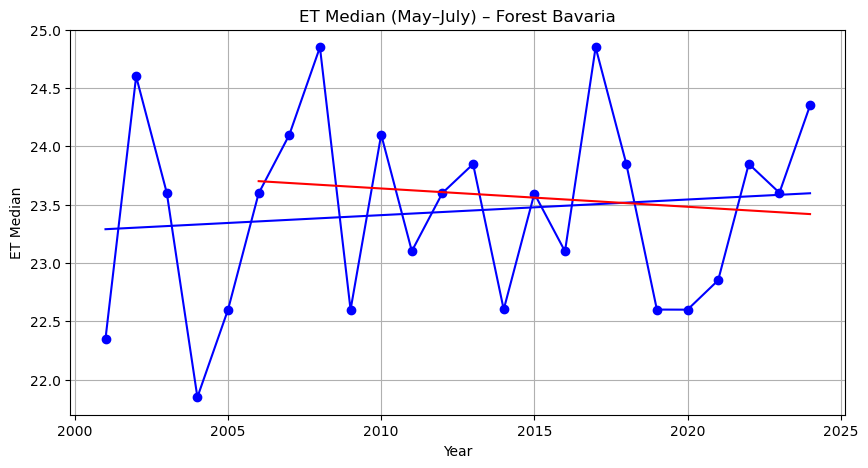

In [9]:
### ET growing season medians of total forests with additional trendline from 2006 onwards



def maskET(image):
    qc = image.select('ET_QC')
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('ET')

ET = (ee.ImageCollection("MODIS/061/MOD16A2GF").filterBounds(bayern).map(maskET))
modis_proj = ET.first().projection()

ET_forest = ET.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


ET_values = []

for year in years:
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    ET_year = (
        ET_forest
        .filterDate(start, end)
        .median()
        .multiply(0.1)
    )

    value = ET_year.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale = modis_proj.nominalScale(),
        maxPixels=1e13
    ).get('ET').getInfo()

    ET_values.append(value)



reg_years = np.array(years)
reg_val = np.array(ET_values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept

years_2006 = np.array([y for y in years if y >= 2006])
values_2006 = np.array([
    v for y, v in zip(years, ET_values) if y >= 2006
], dtype=float)

slope_2006, intercept_2006 = np.polyfit(years_2006, values_2006,1)
trend_2006 = slope_2006 * years_2006 + intercept_2006

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, ET_values, marker='o', color='blue')
plt.plot(reg_years, trend, '-', color='blue')
plt.plot(years_2006, trend_2006, '-', color='red')

plt.xlabel("Year")
plt.ylabel("ET Median")
plt.title("ET Median (May–July) – Forest Bavaria")
plt.grid(True)
plt.show()


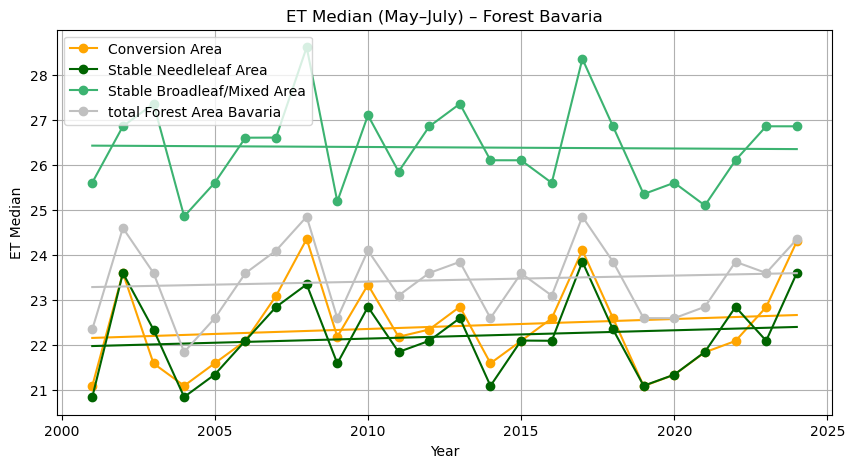


Regression for: Conversion
Slope: 0.022077
Intercept: -22.013555
R²: 0.0250
p-value: 0.460655
Standard Error: 0.029399

Regression for: Needleleaf Stable
Slope: 0.018415
Intercept: -14.865859
R²: 0.0222
p-value: 0.487566
Standard Error: 0.026081

Regression for: Broadleaf/Mixed Stable
Slope: -0.003329
Intercept: 33.086871
R²: 0.0006
p-value: 0.910778
Standard Error: 0.029371

Regression for: Total Forest Bavaria
Slope: 0.013403
Intercept: -3.529840
R²: 0.0134
p-value: 0.590798
Standard Error: 0.024563


In [13]:
### ET growing season medians of different forest structural classes



def maskET(image):
    qc = image.select("ET_QC")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("ET")


ET = ee.ImageCollection("MODIS/061/MOD16A2GF").filterBounds(bayern).map(maskET)
modis_proj = ET.first().projection()

ET_conversion = ET.map(lambda img: img.updateMask(conversion))
ET_needle = ET.map(lambda img: img.updateMask(needle_stable))
ET_broadleaf = ET.map(lambda img: img.updateMask(broadleaf_stable))
ET_forest = ET.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ET_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = NDVI.filterDate(start, end).median().multiply(0.1)

        value = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        ET_values.append(value)
    return ET_values


conversion_values = values(ET_conversion)
needle_values = values(ET_needle)
broadleaf_values = values(ET_broadleaf)
bayern_values = values(ET_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label="total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("ET Median")
plt.title("ET Median (May–July) – Forest Bavaria")
plt.grid(True)
plt.legend(loc= 'upper left')
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

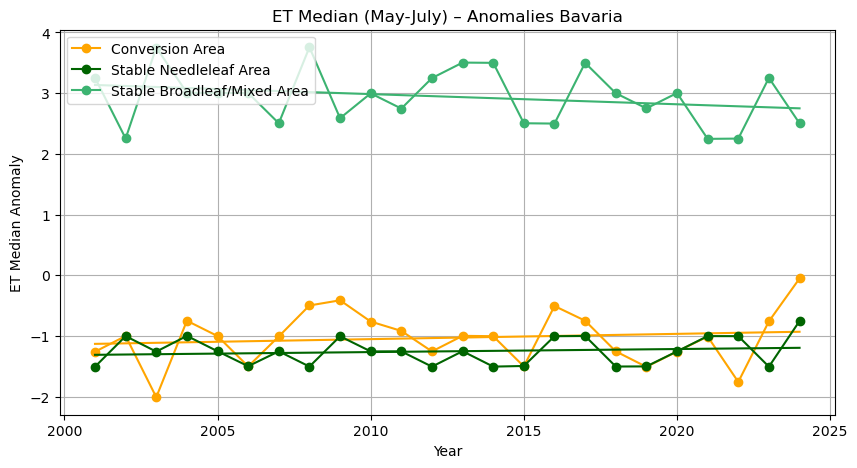


Regression for: Conversion
Slope: 0.008674
Intercept: -18.483715
R²: 0.0189
p-value: 0.521729
Standard Error: 0.013322

Regression for: Needleleaf Stable
Slope: 0.005012
Intercept: -11.336019
R²: 0.0231
p-value: 0.478276
Standard Error: 0.006947

Regression for: Broadleaf/Mixed Stable
Slope: -0.016732
Intercept: 36.616710
R²: 0.0648
p-value: 0.230021
Standard Error: 0.013553


In [14]:
### ET growing season anomalies of different forest structural classes



def maskET(image):
    qc = image.select("ET_QC")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("ET")


ET = ee.ImageCollection("MODIS/061/MOD16A2GF").filterBounds(bayern).map(maskET)
modis_proj = ET.first().projection()

ET_conversion = ET.map(lambda img: img.updateMask(conversion))
ET_needle = ET.map(lambda img: img.updateMask(needle_stable))
ET_broadleaf = ET.map(lambda img: img.updateMask(broadleaf_stable))
ET_forest = ET.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ET_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = NDVI.filterDate(start, end).median().multiply(0.1)

        value = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        ET_values.append(value)
    return ET_values


conversion_values = values(ET_conversion)
needle_values = values(ET_needle)
broadleaf_values = values(ET_broadleaf)
bayern_values = values(ET_forest)


# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("ET Median Anomaly")
plt.title("ET Median (May-July) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

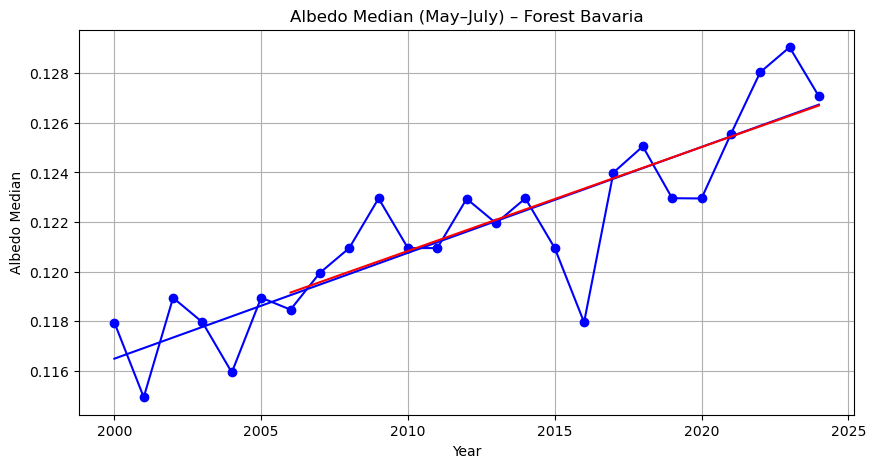

In [23]:
### Albedo growing season median of total forests with additional trendline from 2006 onwards


def maskALB(image):
    qc = image.select('BRDF_Albedo_Band_Mandatory_Quality_shortwave')
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('Albedo_BSA_shortwave')

ALB= (ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(bayern).map(maskALB))
modis_proj = ALB.first().projection()

ALB_forest = ALB.map(lambda img: img.updateMask(forest))


years = list(range(2000, 2025))

ALB_values = []

for year in years:
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    ALB_year = (
        ALB_forest
        .filterDate(start, end)
        .median()
        .multiply(0.001)
    )

    value = ALB_year.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale = modis_proj.nominalScale(),
        maxPixels=1e13
    ).get('Albedo_BSA_shortwave').getInfo()

    ALB_values.append(value)




reg_years = np.array(years)
reg_val = np.array(ALB_values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept

years_2006 = np.array([y for y in years if y >= 2006])
values_2006 = np.array([
    v for y, v in zip(years, ALB_values) if y >= 2006
], dtype=float)

slope_2006, intercept_2006 = np.polyfit(years_2006, values_2006,1)
trend_2006 = slope_2006 * years_2006 + intercept_2006

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, ALB_values, marker='o', color='blue')
plt.plot(reg_years, trend, '-', color='blue')
plt.plot(years_2006, trend_2006, '-', color='red')

plt.xlabel("Year")
plt.ylabel("Albedo Median")
plt.title("Albedo Median (May–July) – Forest Bavaria")
plt.grid(True)
plt.show()


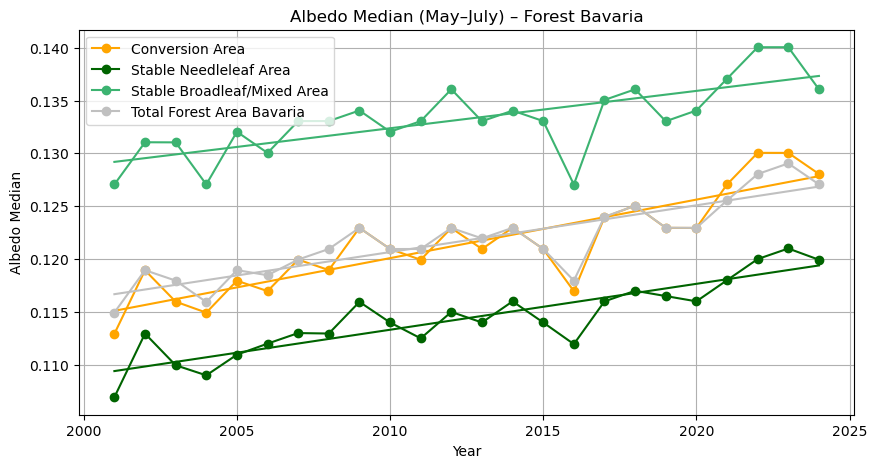


Regression for: Conversion
Slope: 0.000554
Intercept: -0.992885
R²: 0.7522
p-value: 0.000000
Standard Error: 0.000068

Regression for: Needleleaf Stable
Slope: 0.000434
Intercept: -0.759877
R²: 0.7787
p-value: 0.000000
Standard Error: 0.000049

Regression for: Broadleaf/Mixed Stable
Slope: 0.000353
Intercept: -0.578133
R²: 0.5247
p-value: 0.000063
Standard Error: 0.000072

Regression for: Total Forest Bavaria
Slope: 0.000443
Intercept: -0.768924
R²: 0.7512
p-value: 0.000000
Standard Error: 0.000054


In [16]:
### Albedo growing season medians of different forest structural classes


def maskALB(image):
    qc = image.select("BRDF_Albedo_Band_Mandatory_Quality_shortwave")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("Albedo_BSA_shortwave")


ALB = ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(bayern).map(maskALB)
modis_proj = ALB.first().projection()


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_forest = ALB.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
bayern_values = values(ALB_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label="Total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("Albedo Median")
plt.title("Albedo Median (May–July) – Forest Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

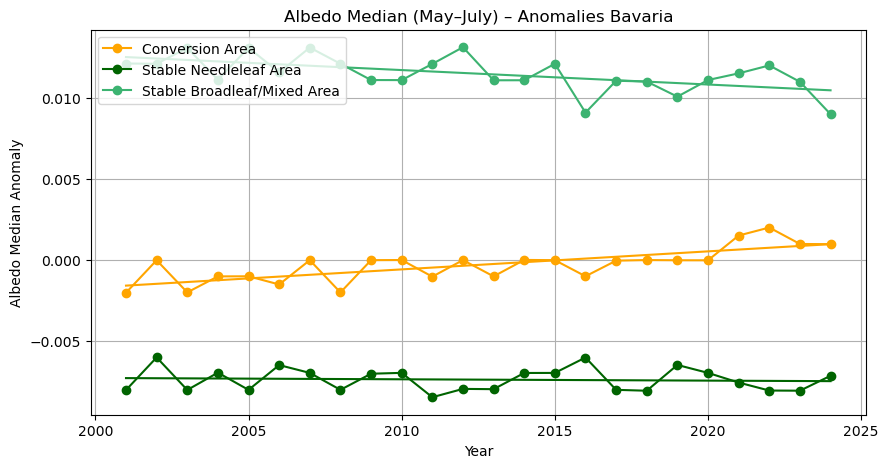


Regression for: Conversion
Slope: 0.000111
Intercept: -0.223961
R²: 0.5578
p-value: 0.000028
Standard Error: 0.000021

Regression for: Needleleaf Stable
Slope: -0.000008
Intercept: 0.009047
R²: 0.0065
p-value: 0.709067
Standard Error: 0.000022

Regression for: Broadleaf/Mixed Stable
Slope: -0.000089
Intercept: 0.190790
R²: 0.3251
p-value: 0.003627
Standard Error: 0.000027


In [17]:
### Albedo growing season anomalies of different forest structural classes


def maskALB(image):
    qc = image.select("BRDF_Albedo_Band_Mandatory_Quality_shortwave")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("Albedo_BSA_shortwave")


ALB = ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(bayern).map(maskALB)
modis_proj = ALB.first().projection()


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_forest = ALB.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
bayern_values = values(ALB_forest)


# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("Albedo Median Anomaly")
plt.title("Albedo Median (May–July) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()


# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

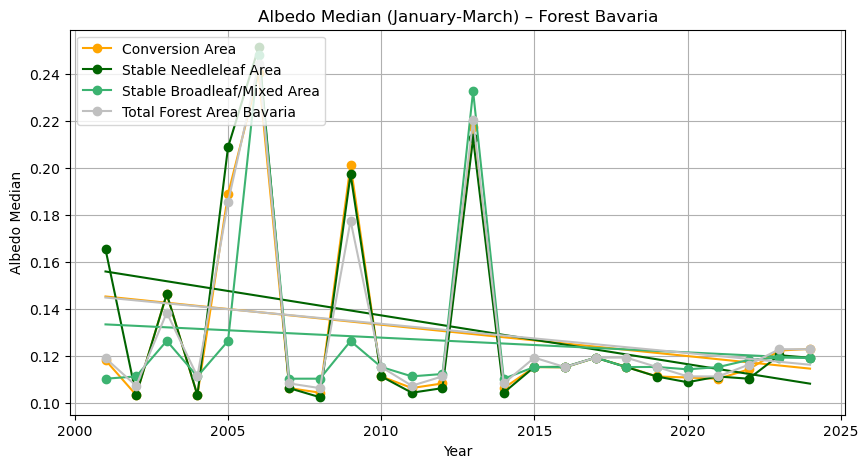


Regression for: Conversion
Slope: -0.001335
Intercept: 2.817098
R²: 0.0576
p-value: 0.258525
Standard Error: 0.001151

Regression for: Needleleaf Stable
Slope: -0.002076
Intercept: 4.309719
R²: 0.1203
p-value: 0.096850
Standard Error: 0.001197

Regression for: Broadleaf/Mixed Stable
Slope: -0.000627
Intercept: 1.387847
R²: 0.0155
p-value: 0.561739
Standard Error: 0.001064

Regression for: Total Forest Bavaria
Slope: -0.001243
Intercept: 2.633015
R²: 0.0556
p-value: 0.267278
Standard Error: 0.001092


In [19]:
### Albedo winter season medians of different forest structural classes



def maskALB(image):
    qc = image.select("BRDF_Albedo_Band_Mandatory_Quality_shortwave")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("Albedo_BSA_shortwave")


ALB = ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(bayern).map(maskALB)
modis_proj = ALB.first().projection()


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_forest = ALB.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
bayern_values = values(ALB_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label= "Total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("Albedo Median")
plt.title("Albedo Median (January-March) – Forest Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()


# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

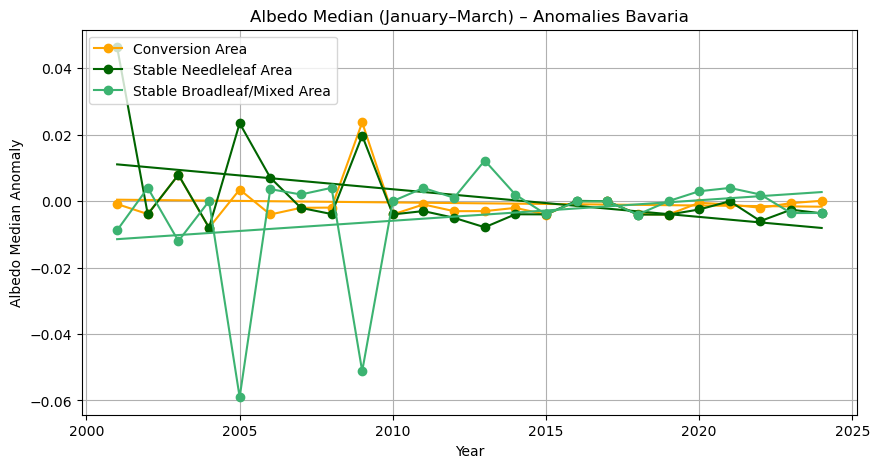


Regression for: Conversion
Slope: -0.000092
Intercept: 0.184083
R²: 0.0118
p-value: 0.614082
Standard Error: 0.000179

Regression for: Needleleaf Stable
Slope: -0.000832
Intercept: 1.676704
R²: 0.2288
p-value: 0.018048
Standard Error: 0.000326

Regression for: Broadleaf/Mixed Stable
Slope: 0.000617
Intercept: -1.245168
R²: 0.0708
p-value: 0.208941
Standard Error: 0.000476


In [20]:
### Albedo winter season anomalies of different forest structural classes


def maskALB(image):
    qc = image.select("BRDF_Albedo_Band_Mandatory_Quality_shortwave")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("Albedo_BSA_shortwave")


ALB = ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(bayern).map(maskALB)
modis_proj = ALB.first().projection()


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_forest = ALB.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
bayern_values = values(ALB_forest)


# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("Albedo Median Anomaly")
plt.title("Albedo Median (January–March) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()


# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

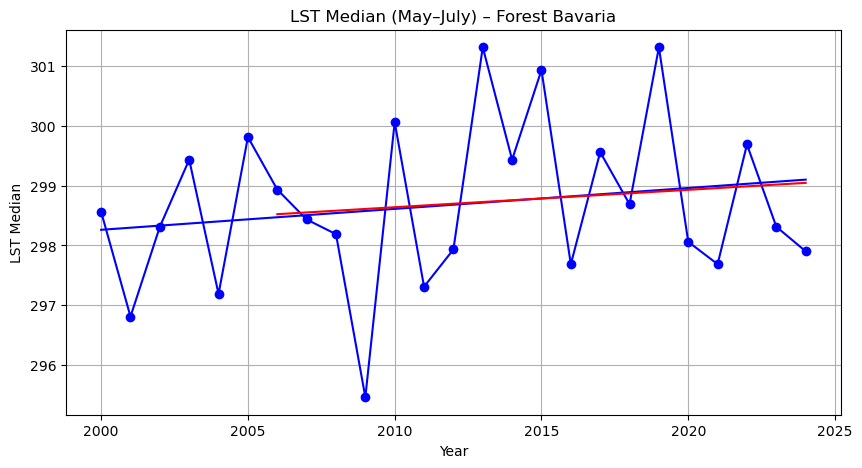

In [6]:
### LST growing season median of total forests with additional trendline from 2006 onwards


def maskLST(image):
    qc = image.select('QC_Day')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select('LST_Day_1km')

LST= (ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(bayern).map(maskLST))
modis_proj = LST.first().projection()

LST_forest = LST.map(lambda img: img.updateMask(forest))


years = list(range(2000, 2025))

LST_values = []

for year in years:
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    LST_year = (
        LST_forest
        .filterDate(start, end)
        .median()
        .multiply(0.02)
    )

    value = LST_year.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale = modis_proj.nominalScale(),
        maxPixels=1e13
    ).get('LST_Day_1km').getInfo()

    LST_values.append(value)




reg_years = np.array(years)
reg_val = np.array(LST_values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept

years_2006 = np.array([y for y in years if y >= 2006])
values_2006 = np.array([
    v for y, v in zip(years, LST_values) if y >= 2006
], dtype=float)

slope_2006, intercept_2006 = np.polyfit(years_2006, values_2006,1)
trend_2006 = slope_2006 * years_2006 + intercept_2006

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, LST_values, marker='o', color='blue')
plt.plot(reg_years, trend, '-', color='blue')
plt.plot(years_2006, trend_2006, '-', color='red')

plt.xlabel("Year")
plt.ylabel("LST Median")
plt.title("LST Median (May–July) – Forest Bavaria")
plt.grid(True)
plt.show()


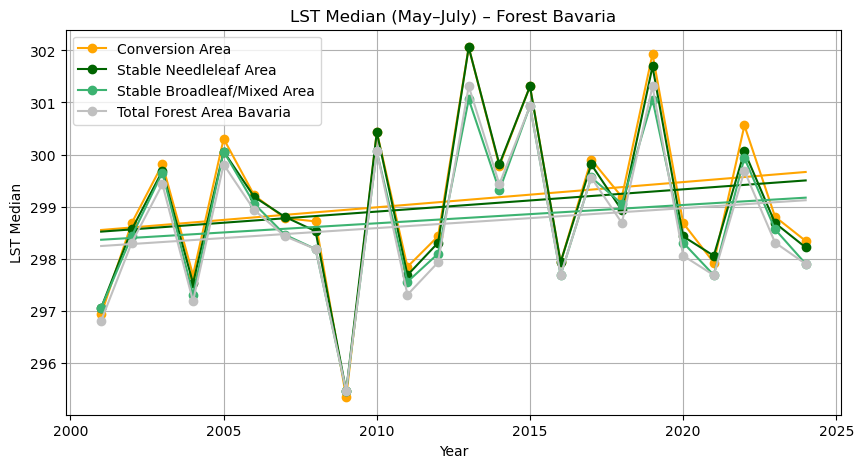


Regression for: Conversion
Slope: 0.048410
Intercept: 201.684910
R²: 0.0486
p-value: 0.300809
Standard Error: 0.045686

Regression for: Needleleaf Stable
Slope: 0.042724
Intercept: 213.030542
R²: 0.0402
p-value: 0.347457
Standard Error: 0.044501

Regression for: Broadleaf/Mixed Stable
Slope: 0.035120
Intercept: 228.089663
R²: 0.0326
p-value: 0.398670
Standard Error: 0.040803

Regression for: Total Forest Bavaria
Slope: 0.038200
Intercept: 221.807263
R²: 0.0356
p-value: 0.377241
Standard Error: 0.042388


In [21]:
### LST growing season medians of different forest structural classes



def maskLST(image):
    qc = image.select("QC_Day")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("LST_Day_1km")


LST = ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(bayern).map(maskLST)
modis_proj = LST.first().projection()


LST_conversion = LST.map(lambda img: img.updateMask(conversion))
LST_needle = LST.map(lambda img: img.updateMask(needle_stable))
LST_broadleaf = LST.map(lambda img: img.updateMask(broadleaf_stable))
LST_forest = LST.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(LST):
    LST_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        value = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        LST_values.append(value)
    return LST_values


conversion_values = values(LST_conversion)
needle_values = values(LST_needle)
broadleaf_values = values(LST_broadleaf)
bayern_values = values(LST_forest)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(bayern_values)

slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, bayern_values, marker="o", color="silver", label="Total Forest Area Bavaria")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("LST Median")
plt.title("LST Median (May–July) – Forest Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()


# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

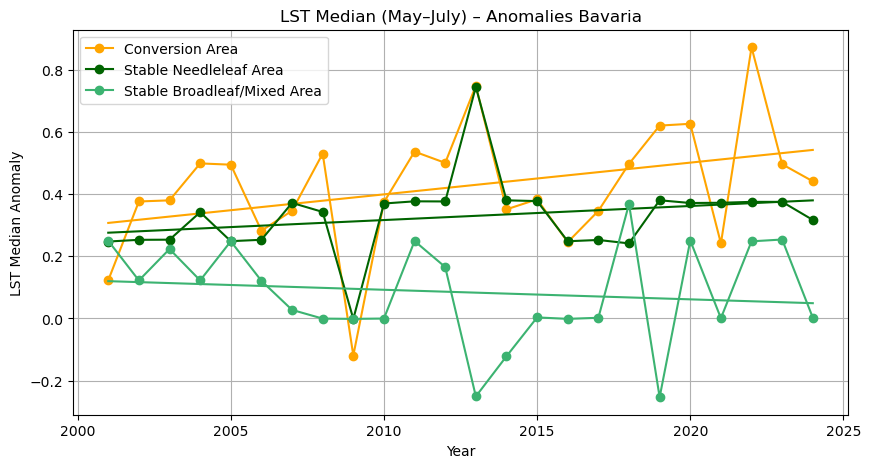


Regression for: Conversion
Slope: 0.010210
Intercept: -20.122352
R²: 0.1283
p-value: 0.085645
Standard Error: 0.005673

Regression for: Needleleaf Stable
Slope: 0.004524
Intercept: -8.776721
R²: 0.0660
p-value: 0.225591
Standard Error: 0.003629

Regression for: Broadleaf/Mixed Stable
Slope: -0.003080
Intercept: 6.282401
R²: 0.0181
p-value: 0.531065
Standard Error: 0.004839


In [22]:
### LST growing season anomalies of different forest structural classes



def maskLST(image):
    qc = image.select("QC_Day")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("LST_Day_1km")


LST = ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(bayern).map(maskLST)
modis_proj = LST.first().projection()


LST_conversion = LST.map(lambda img: img.updateMask(conversion))
LST_needle = LST.map(lambda img: img.updateMask(needle_stable))
LST_broadleaf = LST.map(lambda img: img.updateMask(broadleaf_stable))
LST_forest = LST.map(lambda img: img.updateMask(forest))


years = list(range(2001, 2025))


def values(LST):
    LST_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        value = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        LST_values.append(value)
    return LST_values


conversion_values = values(LST_conversion)
needle_values = values(LST_needle)
broadleaf_values = values(LST_broadleaf)
bayern_values = values(LST_forest)



# Regression
reg_years = np.array(years)
conv = np.array(conversion_values)
need = np.array(needle_values)
broad = np.array(broadleaf_values)
total = np.array(bayern_values)

conv_delta  = conv  - total
need_delta  = need  - total
broad_delta = broad - total

slope1, intercept1 = np.polyfit(reg_years, conv_delta, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, need_delta, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, broad_delta, 1)
trend3 = slope3 * reg_years + intercept3


# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conv_delta, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, need_delta, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broad_delta, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")

plt.xlabel("Year")
plt.ylabel("LST Median Anomaly")
plt.title("LST Median (May–July) – Anomalies Bavaria")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()


# Stats
regression_values = [
    ("Conversion", conv_delta),
    ("Needleleaf Stable", need_delta),
    ("Broadleaf/Mixed Stable", broad_delta),
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\nRegression for: {name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")